# Tasks 4.3 and 4.9

## Task 4.3

**4.3 predict magnitude of antibody response - Vic B/Austria/1359417/2021 (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI
* Measure: Single strain titer
* Metric: Spearman correlation
* Full description: HAI titer for Vic B/Austria/1359417/2021 at Day 28

Magnitude refers to the strength of the antibody response against a single specific vaccine strain.
We are predicting the HAI titer for Vic B/Austria/1359417/2021 at Day 28 post-vaccination.

## Task 4.9

**4.9 Predict antibody durability - Vic B/Austria/1359417/2021 (D365)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI
* Measure: Post-vac HAI
* Metric: Spearman correlation
* Full description: Post-vac HAI of the B Victoria vaccine strain at Day 365

Durability refers to how well the antibody response is maintained over time after vaccination.
We are predicting the post-vaccination HAI titer for Vic B/Austria/1359417/2021 at Day 365 post-vaccination.

## NOTE: y-values are log-2 transformed, however, since we are using Spearman the ordering is what matters and there is no need to reverse this transformation

In [1]:
TARGET_COL_4_3 = 'HAI_Vic B/Austria/1359417/2021_d28'  # task 4.3

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.pipeline import Pipeline

In [3]:
DATA_PATH = 'cleaned_data'
train_participants = pd.read_csv(DATA_PATH + '/participants_cleaned.csv')
train_hai = pd.read_csv(DATA_PATH + '/hai_cleaned.csv')
tables = {
    'train_hai': train_hai,
    'train_participants': train_participants
}

In [4]:
for name, df in tables.items():
    print(f"\n{'=' * 50}")
    print(f'TABLE: {name}')
    print(f"{'=' * 50}")
    display(df.head(5))


TABLE: train_hai


,participant_id,HAI_Anc B/Lee/1940_d0,HAI_Anc B/Lee/1940_d28,HAI_Anc B/Lee/1940_d365,HAI_Anc B/Maryland/1959_d0,HAI_Anc B/Maryland/1959_d28,HAI_Anc B/Singapore/1964_d0,HAI_Anc B/Singapore/1964_d28,HAI_H1N1 A/Beijing/262/1995_d0,HAI_H1N1 A/Beijing/262/1995_d28,...,HAI_Yam B/Sichuan/379/1999_d365,HAI_Yam B/Texas/6/2011_d0,HAI_Yam B/Texas/6/2011_d28,HAI_Yam B/Texas/6/2011_d365,HAI_Yam B/Wisconsin/1/2010_d0,HAI_Yam B/Wisconsin/1/2010_d28,HAI_Yam B/Wisconsin/1/2010_d365,HAI_Yam B/Yamagata/16/1988_d0,HAI_Yam B/Yamagata/16/1988_d28,HAI_Yam B/Yamagata/16/1988_d365
0,2016_UGA.ID_001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.321928,5.321928,...,NaN,7.321928,8.321928,NaN,8.321928,8.321928,NaN,7.321928,8.321928,NaN
1,2016_UGA.ID_002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.321928,5.321928,...,NaN,5.321928,6.321928,NaN,6.321928,6.321928,NaN,5.321928,5.321928,NaN
2,2016_UGA.ID_003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.321928,5.321928,...,NaN,8.321928,8.321928,NaN,8.321928,8.321928,NaN,8.321928,8.321928,NaN
3,2016_UGA.ID_004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.321928,5.321928,...,NaN,4.321928,6.321928,NaN,5.321928,6.321928,NaN,3.321928,5.321928,NaN
4,2016_UGA.ID_005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.321928,2.321928,...,6.321928,6.321928,6.321928,5.321928,6.321928,6.321928,5.321928,5.321928,5.321928,5.321928



TABLE: train_participants


,participant_id,PART_biological_sex,PART_race,PART_geolocation,PART_arm_name,PART_age
0,SDY269.SUB112836,Female,White,Georgia,Other,28.0
1,SDY269.SUB112849,Female,Black,Georgia,Other,39.0
2,SDY269.SUB112854,Male,Black,Georgia,Other,46.0
3,SDY269.SUB112860,Female,White,Georgia,Other,32.0
4,SDY269.SUB112881,Female,Black,Georgia,Other,29.0


### Data is pre-cleaned
Both tables are already one row per participant with cleaned column names:
- HAI columns follow `HAI_{strain}_d{timepoint}` format
- Participant columns follow `PART_{field}` format

We just need to merge them and separate features from target.

In [5]:
# Merge HAI and participant tables
data = train_hai.merge(train_participants, on='participant_id', how='inner')
print(f'Merged shape: {data.shape}')
data.head()

Merged shape: (3757, 201)


,participant_id,HAI_Anc B/Lee/1940_d0,HAI_Anc B/Lee/1940_d28,HAI_Anc B/Lee/1940_d365,HAI_Anc B/Maryland/1959_d0,HAI_Anc B/Maryland/1959_d28,HAI_Anc B/Singapore/1964_d0,HAI_Anc B/Singapore/1964_d28,HAI_H1N1 A/Beijing/262/1995_d0,HAI_H1N1 A/Beijing/262/1995_d28,...,HAI_Yam B/Wisconsin/1/2010_d28,HAI_Yam B/Wisconsin/1/2010_d365,HAI_Yam B/Yamagata/16/1988_d0,HAI_Yam B/Yamagata/16/1988_d28,HAI_Yam B/Yamagata/16/1988_d365,PART_biological_sex,PART_race,PART_geolocation,PART_arm_name,PART_age
0,2016_UGA.ID_001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.321928,5.321928,...,8.321928,NaN,7.321928,8.321928,NaN,Female,Unknown,Georgia,Standard Fluzone,29.0
1,2016_UGA.ID_002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.321928,5.321928,...,6.321928,NaN,5.321928,5.321928,NaN,Female,Unknown,Georgia,Standard Fluzone,29.0
2,2016_UGA.ID_003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.321928,5.321928,...,8.321928,NaN,8.321928,8.321928,NaN,Female,Unknown,Georgia,Standard Fluzone,28.0
3,2016_UGA.ID_004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.321928,5.321928,...,6.321928,NaN,3.321928,5.321928,NaN,Male,Unknown,Georgia,Standard Fluzone,27.0
4,2016_UGA.ID_005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.321928,2.321928,...,6.321928,5.321928,5.321928,5.321928,5.321928,Female,Unknown,Georgia,Standard Fluzone,25.0


In [6]:
# Features: only d0 HAI columns + participant columns (no future data)
feature_cols = [c for c in data.columns
                if c != 'participant_id'
                and c != TARGET_COL_4_3
                and not c.endswith('_d28')
                and not c.endswith('_d365')]

print(f'Target: {TARGET_COL_4_3}')
print(f'Features: {len(feature_cols)}')
print(f'Sample feature names: {feature_cols[:5]}')

Target: HAI_Vic B/Austria/1359417/2021_d28
Features: 73
Sample feature names: ['HAI_Anc B/Lee/1940_d0', 'HAI_Anc B/Maryland/1959_d0', 'HAI_Anc B/Singapore/1964_d0', 'HAI_H1N1 A/Beijing/262/1995_d0', 'HAI_H1N1 A/Brazil/11/1978_d0']


### Build X and y

In [7]:
# Target: single strain HAI titer at Day 28
y_vals = data[TARGET_COL_4_3].copy()

# Drop rows where target is NaN
mask = y_vals.notna()
y_vals = y_vals[mask]
X = data.loc[mask, feature_cols].copy()

# y-values already log-transformed, so no need to log2 them

print(f'Samples: {len(X)}')
print(f'Features: {X.shape[1]}')

Samples: 920
Features: 73


### Encode categorical features

In [8]:
# One-hot encode any categorical PART_ columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
if cat_cols:
    print(f'Encoding categorical columns: {cat_cols}')
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f'Final feature count: {X.shape[1]}')

Encoding categorical columns: ['PART_biological_sex', 'PART_race', 'PART_geolocation', 'PART_arm_name']
Final feature count: 71


/var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/ipykernel_6562/398821456.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


In [9]:
X.head()

,HAI_Anc B/Lee/1940_d0,HAI_Anc B/Maryland/1959_d0,HAI_Anc B/Singapore/1964_d0,HAI_H1N1 A/Beijing/262/1995_d0,HAI_H1N1 A/Brazil/11/1978_d0,HAI_H1N1 A/Brisbane/2/2018_d0,HAI_H1N1 A/Brisbane/59/2007_d0,HAI_H1N1 A/California/7/2009_d0,HAI_H1N1 A/Chile/1/1983_d0,HAI_H1N1 A/Denver/1/1957_d0,...,HAI_Yam B/Harbin/7/1994_d0,HAI_Yam B/Massachusetts/2/2012_d0,HAI_Yam B/Phuket/3073/2013_d0,HAI_Yam B/Sichuan/379/1999_d0,HAI_Yam B/Texas/6/2011_d0,HAI_Yam B/Wisconsin/1/2010_d0,HAI_Yam B/Yamagata/16/1988_d0,PART_age,PART_biological_sex_Male,PART_arm_name_Standard Fluzone
809,NaN,NaN,NaN,NaN,NaN,5.321928,NaN,5.321928,NaN,NaN,...,NaN,NaN,8.321928,NaN,NaN,NaN,NaN,32.0,False,True
810,NaN,NaN,NaN,NaN,NaN,2.321928,NaN,4.321928,NaN,NaN,...,NaN,NaN,5.321928,NaN,NaN,NaN,NaN,28.0,False,True
811,NaN,NaN,NaN,NaN,NaN,4.321928,NaN,4.321928,NaN,NaN,...,NaN,NaN,4.321928,NaN,NaN,NaN,NaN,50.0,False,True
812,NaN,NaN,NaN,NaN,NaN,6.321928,NaN,8.321928,NaN,NaN,...,NaN,NaN,9.321928,NaN,NaN,NaN,NaN,29.0,False,True
813,NaN,NaN,NaN,NaN,NaN,2.321928,NaN,3.321928,NaN,NaN,...,NaN,NaN,2.321928,NaN,NaN,NaN,NaN,65.0,False,False


### Train model

**Why Spearman correlation?**

This task uses Spearman correlation as its evaluation metric. Spearman only cares about
**rankings**. It converts all your true values and predictions into ranks (1st, 2nd, 3rd…)
and then checks whether those two rank orderings agree.

This is a good fit for antibody data because:
- HAI titers are noisy and vary across studies, so predicting exact values is unrealistic.
- What matters clinically is *relative* response: can we identify who will respond well vs. poorly?
- Spearman is also robust to outliers and non-linear relationships — if your predictions are
  monotonically related to the truth (always going in the right direction), Spearman rewards that
  even if the relationship isn't a straight line.

**Interpreting the score:**
A Spearman of 1.0 means perfect ranking agreement, 0.0 means no relationship, and -1.0 means
perfectly reversed rankings.

In [10]:
# Simple pipeline: impute remaining NaNs, then regress
model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('regressor', LinearRegression())
])

# --- Cross-validated evaluation (the real score) ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(model, X, y_vals, cv=cv)
rho_cv, pval_cv = spearmanr(y_vals, y_pred_cv)
print(f'Spearman (5-fold CV): {rho_cv:.3f}  (p-value: {pval_cv:.4f})')

Spearman (5-fold CV): 0.694  (p-value: 0.0000)


/Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['HAI_Anc B/Lee/1940_d0' 'HAI_Anc B/Maryland/1959_d0'
 'HAI_Anc B/Singapore/1964_d0' 'HAI_H1N1 A/Beijing/262/1995_d0'
 'HAI_H1N1 A/Brazil/11/1978_d0' 'HAI_H1N1 A/Brisbane/59/2007_d0'
 'HAI_H1N1 A/Chile/1/1983_d0' 'HAI_H1N1 A/Denver/1/1957_d0'
 'HAI_H1N1 A/Fort Monmouth/1/1947_d0' 'HAI_H1N1 A/Hawaii/70/2019_d0'
 'HAI_H1N1 A/New Caledonia/20/1999_d0' 'HAI_H1N1 A/New Jersey/8/1976_d0'
 'HAI_H1N1 A/Puerto Rico/8/1934_d0' 'HAI_H1N1 A/Singapore/6/1986_d0'
 'HAI_H1N1 A/Solomon Islands/3/2006_d0'
 'HAI_H1N1 A/South Carolina/1/1918_d0' 'HAI_H1N1 A/South Dakota/6/2007_d0'
 'HAI_H1N1 A/Texas/36/1991_d0' 'HAI_H1N1 A/USSR/90/1977_d0'
 'HAI_H1N1 A/Weiss/JY2/1943_d0' 'HAI_H3N2 A/Brisbane/10/2007_d0'
 'HAI_H3N2 A/Hong Kong/1/1968_d0' 'HAI_H3N2 A/Mississippi/1/1985_d0'
 'HAI_H3N2 A/Nanchang/933/1995_d0' 'HAI_H3N2 A/New Y

### Why Cross-Validation?

The CV score above is our real evaluation. Each participant's prediction was made by a model
that **never saw that participant during training** (5-fold: train on 4/5 of the data, predict
the held-out 1/5, rotate). This tells us how the model would perform on new, unseen participants.

The train score is shown only as an overfitting diagnostic — a large gap between train and CV
means the model memorised noise rather than learning real patterns.

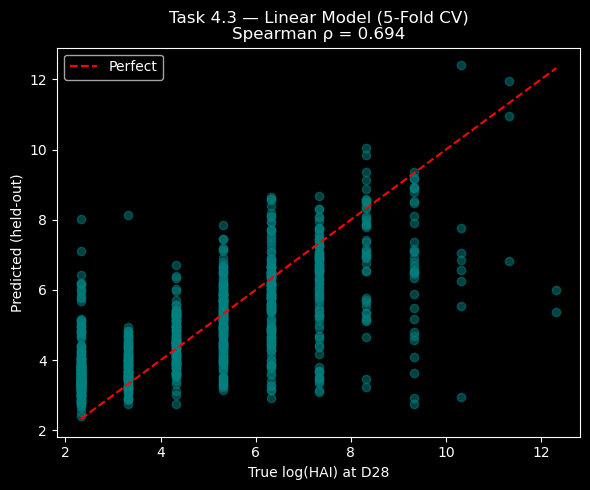

In [11]:
plt.figure(figsize=(6, 5))
plt.scatter(y_vals, y_pred_cv, alpha=0.5, color='teal')
plt.plot([y_vals.min(), y_vals.max()], [y_vals.min(), y_vals.max()], 'r--', label='Perfect')
plt.xlabel('True log(HAI) at D28')
plt.ylabel('Predicted (held-out)')
plt.title(f'Task 4.3 — Linear Model (5-Fold CV)\nSpearman ρ = {rho_cv:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
results = pd.DataFrame({
    'participant_id': data.loc[mask, 'participant_id'].values,
    'predicted_hai_d28': np.expm1(y_pred_cv),  # reverse the log1p transform
})
results

,participant_id,predicted_hai_d28
0,2020_UGA.ID_001,40.422269
1,2020_UGA.ID_005,33.609239
2,2020_UGA.ID_008,32.991837
3,2020_UGA.ID_011,44.640382
4,2020_UGA.ID_014,26.112035
...,...,...
915,2023_UGA.ID_750,60.857180
916,2023_UGA.ID_751,46.161099
917,2023_UGA.ID_753,313.838835
918,2023_UGA.ID_754,228.893890


In [13]:
rmse = np.sqrt(mean_squared_error(y_vals, y_pred_cv))
mse = mean_squared_error(y_vals, y_pred_cv)
mae = mean_absolute_error(y_vals, y_pred_cv)
rmsle = np.sqrt(mean_squared_error(np.log1p(y_vals), np.log1p(y_pred_cv)))

print(f"{'Model':<40} {'RMSE':>8} {'MSE':>10} {'MAE':>8} {'RMSLE':>8}")
print(f"{'Linear Regression (5-Fold CV)':<40} {rmse:>8.4f} {mse:>10.4f} {mae:>8.4f} {rmsle:>8.4f}")

Model                                        RMSE        MSE      MAE    RMSLE
Linear Regression (5-Fold CV)              1.5498     2.4018   1.1455   0.2682


In [14]:
# output to csv
results = pd.DataFrame({
    'participant_id': data.loc[mask, 'participant_id'].values,
    'Task_4.3': np.expm1(y_pred_cv),  # reverse the log1p transform
})
results.to_csv('submission/task_4_3.csv', index=False)
results

,participant_id,Task_4.3
0,2020_UGA.ID_001,40.422269
1,2020_UGA.ID_005,33.609239
2,2020_UGA.ID_008,32.991837
3,2020_UGA.ID_011,44.640382
4,2020_UGA.ID_014,26.112035
...,...,...
915,2023_UGA.ID_750,60.857180
916,2023_UGA.ID_751,46.161099
917,2023_UGA.ID_753,313.838835
918,2023_UGA.ID_754,228.893890
